In [12]:
import cv2
import numpy as np
import pandas as pd
import os
import sys
import math
from matplotlib import pyplot as plt
from IPython.display import display, clear_output
from skimage import data


# Agregar la ruta al folder src/
sys.path.append(os.path.abspath('../src'))
from matching import *
from utils import *

In [13]:
# Directorios de salida
BASE_DIR = 'C:/Users/deivi/OneDrive/Escritorio/U/ComputerVision/Trabajo2/'#Modificar
SYNTHETIC_DATA_DIR = os.path.join(BASE_DIR, 'data/synthetic/')
FIGURES_DIR = os.path.join(BASE_DIR, 'results/figures/')

1. Importamos la imagen

In [14]:
try:
    img_base = cv2.imread(os.path.join(BASE_DIR, 'data/original/IMG01.jpg'), cv2.IMREAD_GRAYSCALE)
    if img_base is None:
        raise FileNotFoundError("Asegúrate de que 'image_ff5098.jpg' esté en el directorio correcto.")
        
except FileNotFoundError as e:
    print(e)

2. Definir los Parámetros y Construir H_true (Ground Truth)

In [15]:
# Parámetros conocidos para una transformación de Homografía
angulo_deg = 15.0     # Rotación 15 grados
escala = 1.15         # Escalamiento 15% más grande
tx = 80               # Traslación en X 80 píxeles a la derecha
ty = -30              # Traslación en Y 30 píxeles hacia arriba
p_x = 0.0003          # Perspectiva en X
p_y = -0.0004         # Perspectiva en Y

# Almacenar los parámetros para referencia en el reporte
transform_params = {
    'angle': angulo_deg, 'scale': escala, 'tx': tx, 'ty': ty, 'p_x': p_x, 'p_y': p_y
}

# Construcción de la Matriz H_true
theta = np.deg2rad(angulo_deg)
R_S = np.array([
    [escala * np.cos(theta), -escala * np.sin(theta)],
    [escala * np.sin(theta), escala * np.cos(theta)]
])
H_true = np.eye(3, dtype=np.float32)
H_true[:2, :2] = R_S
H_true[:2, 2] = [tx, ty]
H_true[2, :2] = [p_x, p_y]

print("H_true (Ground Truth) generada:")
print(H_true)

H_true (Ground Truth) generada:
[[ 1.1108147e+00 -2.9764190e-01  8.0000000e+01]
 [ 2.9764190e-01  1.1108147e+00 -3.0000000e+01]
 [ 3.0000001e-04 -3.9999999e-04  1.0000000e+00]]


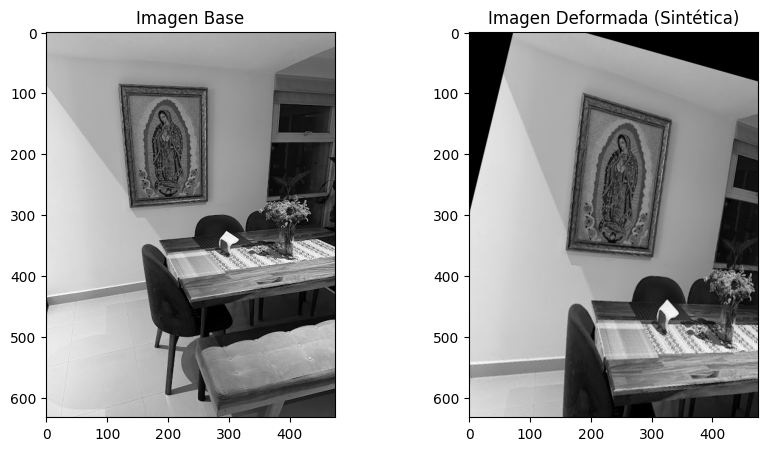

In [16]:
# 3. Aplicar H_true para crear la imagen deformada
alto, ancho = img_base.shape[:2]

# Aplicar la Homografía H_true a la imagen base
# El tamaño del output es el mismo que el input para la validación
img_deformada = cv2.warpPerspective(img_base, H_true, (ancho, alto))

# Guardar las imágenes sintéticas generadas
cv2.imwrite(os.path.join(SYNTHETIC_DATA_DIR, 'base_sintetica.png'), img_base)
cv2.imwrite(os.path.join(SYNTHETIC_DATA_DIR, 'deformada_sintetica.png'), img_deformada)

# Visualización para verificación
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(img_base, cmap='gray'); plt.title('Imagen Base')
plt.subplot(1, 2, 2); plt.imshow(img_deformada, cmap='gray'); plt.title('Imagen Deformada (Sintética)')
plt.show() #

Ejecución del Pipeline de Registro y Validación Inicial

In [17]:
# PARÁMETROS DEL EXPERIMENTO
DETECTOR_INICIAL = "SIFT"  # O "ORB" o "AKAZE"
RANSAC_INICIAL = 5.0
RATIO_UMBRAL = 0.75

In [18]:
# 1. Detección y Descripción de Características
print("Paso 1: Detectando características...")
kp_base, des_base = detectar_y_describir(img_base, DETECTOR_INICIAL)
kp_deformada, des_deformada = detectar_y_describir(img_deformada, DETECTOR_INICIAL)

print(f"Keypoints detectados: {len(kp_base)} en Base, {len(kp_deformada)} en Deformada.")

Paso 1: Detectando características...
Keypoints detectados: 668 en Base, 1053 en Deformada.


In [19]:
# 2. Emparejamiento de Características y Filtro de Ratio
print("Paso 2: Emparejando y filtrando con Ratio Test...")
matches = emparejar_y_filtrar(des_base, des_deformada, DETECTOR_INICIAL, ratio_umbral=RATIO_UMBRAL)

print(f"Matches robustos iniciales: {len(matches)}")

Paso 2: Emparejando y filtrando con Ratio Test...
Matches robustos iniciales: 321


In [20]:
# 3. Estimación de Homografía con RANSAC y Cálculo de Métricas
print("Paso 3: Estimando Homografía con RANSAC...")
H_est, inliers, metrics, corrected_matches = estimate_homography_and_metrics(
    kp_base, 
    kp_deformada, 
    matches, 
    H_gt=H_true,             # Usamos la H_true de la Celda 8 para la validación
    ransac_thresh=RANSAC_INICIAL
)

Paso 3: Estimando Homografía con RANSAC...



--- Resultados del Registro ---
 - num_matches: 321
 - num_inliers: 311
 - inlier_ratio: 0.9688
 - rmse_reprojection: 0.6928
 - homography_error: 0.0523
 - error_convencion: Directa (H_gt_inv * H_est)
 - angular_error_deg: 0.0957

Visualizando los Inliers (Matches correctos)...


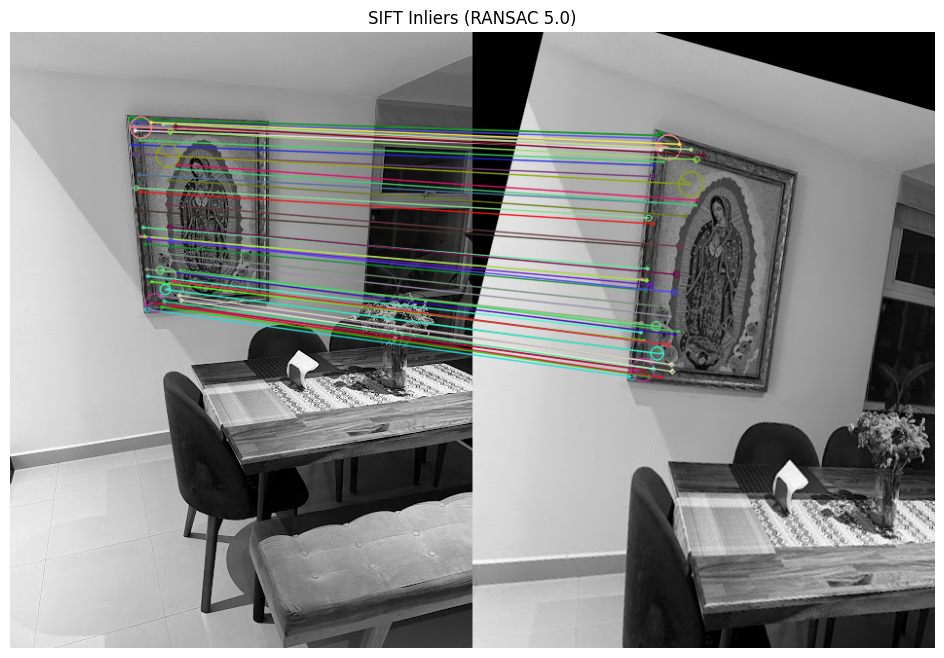

Figura guardada en: C:/Users/deivi/OneDrive/Escritorio/U/ComputerVision/Trabajo2/results/figures/SIFT_inliers_RANSAC5.0.png


In [21]:
# 4. Presentación de Resultados y Métricas
if H_est is not None:
    print("\n--- Resultados del Registro ---")
    
    # Imprimir métricas de registro
    for key, value in metrics.items():
        if isinstance(value, (float, np.float32, np.float64)):
            print(f" - {key}: {value:.4f}")
        else:
            print(f" - {key}: {value}")
            
    # Visualización de Keypoints Inlier (para el reporte)
    print("\nVisualizando los Inliers (Matches correctos)...")
    draw_matches_and_save(
        img_base, kp_base, img_deformada, kp_deformada, 
        corrected_matches[:50], # Mostrar solo los primeros 50 inliers para claridad
        f'{DETECTOR_INICIAL} Inliers (RANSAC {RANSAC_INICIAL})', # Título
        FIGURES_DIR,
        f'{DETECTOR_INICIAL}_inliers_RANSAC{RANSAC_INICIAL}.png' # Filename
    )
    # 
else:
    print("\n No se pudo estimar la Homografía (muy pocos inliers o error).")


# Guardar los resultados iniciales para su posterior comparación en la Celda 10
initial_results = {
    'detector': DETECTOR_INICIAL,
    'metrics': metrics
}

In [22]:
# Análisis del Impacto del Umbral RANSAC
# Umbrales RANSAC a probar
ransac_valores = [1.0, 3.0, 5.0, 10.0] 
resultados_ransac = []
DETECTOR = "SIFT" 

print(f"--- Análisis: Variación del Umbral RANSAC con {DETECTOR} ---")

for thresh in ransac_valores:
    print(f"-> Ejecutando con RANSAC_THRESH = {thresh}...")
    
    H_est, inliers, metrics, corrected_matches = estimate_homography_and_metrics(
        kp_base, 
        kp_deformada, 
        matches, 
        H_gt=H_true,             
        ransac_thresh=thresh
    )
    
    if H_est is not None:
        # Almacenar las métricas relevantes, incluyendo el umbral
        resultados_ransac.append({
            'Detector': DETECTOR,
            'RANSAC_Thresh': thresh,
            'Num_Inliers': metrics.get('num_inliers', 0),
            'Inlier_Ratio': metrics.get('inlier_ratio', 0.0),
            'RMSE_Repro': metrics.get('rmse_reprojection', np.nan),
            'H_Error': metrics.get('homography_error', np.nan),
            'Ang_Error': metrics.get('angular_error_deg', np.nan),
            'Convencion': metrics.get('error_convencion', 'N/A')
        })
            
    else:
        print(f"  Estimación fallida para RANSAC_THRESH = {thresh}.")
        resultados_ransac.append({'RANSAC_Thresh': thresh, 'Error': 'Estimación Fallida'})

print("\n--- Resultados de la Variación de RANSAC ---")
df_ransac = pd.DataFrame(resultados_ransac)
display(df_ransac)

--- Análisis: Variación del Umbral RANSAC con SIFT ---
-> Ejecutando con RANSAC_THRESH = 1.0...
-> Ejecutando con RANSAC_THRESH = 3.0...
-> Ejecutando con RANSAC_THRESH = 5.0...
-> Ejecutando con RANSAC_THRESH = 10.0...

--- Resultados de la Variación de RANSAC ---


,Detector,RANSAC_Thresh,Num_Inliers,Inlier_Ratio,RMSE_Repro,H_Error,Ang_Error,Convencion
0,SIFT,1.0,279,0.869159,0.349069,0.544770,0.019422,Directa (H_gt_inv * H_est)
1,SIFT,3.0,307,0.956386,0.598095,0.051217,0.049670,Directa (H_gt_inv * H_est)
2,SIFT,5.0,311,0.968847,0.692818,0.052255,0.095729,Directa (H_gt_inv * H_est)
3,SIFT,10.0,312,0.971963,0.840866,0.280086,0.068686,Directa (H_gt_inv * H_est)
